In [1]:
import sys

print("Python is working!")
print(sys.executable)

Python is working!
c:\Users\baitu\anaconda3\python.exe


In [5]:
import pandas as pd

# Load the MovieLens datasets
movies = pd.read_csv("../Data/Raw/movies.csv")
ratings = pd.read_csv("../Data/Raw/ratings.csv")
tags = pd.read_csv("../Data/Raw/tags.csv")
links = pd.read_csv("../Data/Raw/links.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)
print("Tags:", tags.shape)
print("Links:", links.shape)

Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)


In [6]:
print("MOVIES")
display(movies.head())

print("\nRATINGS")
display(ratings.head())

print("\nTAGS")
display(tags.head())

print("\nLINKS")
display(links.head())

MOVIES


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



RATINGS


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



TAGS


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200



LINKS


,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [7]:
print("Missing values:")
print("\nMovies:")
print(movies.isnull().sum())

print("\nRatings:")
print(ratings.isnull().sum())

print("\nTags:")
print(tags.isnull().sum())

print("\nLinks:")
print(links.isnull().sum())

print("\nDuplicate rows:")
print("Movies:", movies.duplicated().sum())
print("Ratings:", ratings.duplicated().sum())
print("Tags:", tags.duplicated().sum())
print("Links:", links.duplicated().sum())

Missing values:

Movies:
movieId    0
title      0
genres     0
dtype: int64

Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Links:
movieId    0
imdbId     0
tmdbId     8
dtype: int64

Duplicate rows:
Movies: 0
Ratings: 0
Tags: 0
Links: 0


In [8]:
# Count how many movies belong to each genre

genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

print("Number of movies by genre:")
display(genre_counts)

Number of movies by genre:


genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64

In [9]:
# Create a working copy for processing
movies_processed = movies.copy()

print("Original movies shape:", movies.shape)
print("Processed working copy shape:", movies_processed.shape)

Original movies shape: (9742, 3)
Processed working copy shape: (9742, 3)


In [10]:
# Replace movies with no listed genres with an empty value
movies_processed["genres"] = movies_processed["genres"].replace(
    "(no genres listed)", ""
)

# Check the result
print("Movies with no listed genres:")
print((movies_processed["genres"] == "").sum())

Movies with no listed genres:
34


In [11]:
# Create binary genre features
genre_features = movies_processed["genres"].str.get_dummies(sep="|")

print("Genre feature shape:", genre_features.shape)

display(genre_features.head())

Genre feature shape: (9742, 19)


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
# Combine movie information with the genre features
movies_features = pd.concat(
    [
        movies_processed[["movieId", "title"]],
        genre_features
    ],
    axis=1
)

print("Movies features shape:", movies_features.shape)

display(movies_features.head())

Movies features shape: (9742, 21)


,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

# Select only the genre columns for similarity calculation
genre_matrix = movies_features.iloc[:, 2:]

print("Genre matrix shape:", genre_matrix.shape)

Genre matrix shape: (9742, 19)


In [14]:
# Calculate cosine similarity between all movies
similarity_matrix = cosine_similarity(genre_matrix)

print("Similarity matrix shape:", similarity_matrix.shape)

Similarity matrix shape: (9742, 9742)


In [16]:
def recommend_movies(movie_title, num_recommendations=10):
    # Find the movie
    movie_matches = movies_features[
        movies_features["title"].str.lower() == movie_title.lower()
    ]

    if movie_matches.empty:
        return f"Movie '{movie_title}' was not found."

    # Get the index of the movie
    movie_index = movie_matches.index[0]

    # Get similarity scores for that movie
    similarity_scores = similarity_matrix[movie_index]

    # Sort movies by similarity score
    similar_indices = similarity_scores.argsort()[::-1]

    # Remove the movie itself
    similar_indices = [
        index for index in similar_indices
        if index != movie_index
    ]

    # Get the top recommendations
    top_indices = similar_indices[:num_recommendations]

    recommendations = movies_features.loc[
        top_indices, ["movieId", "title"]
    ].copy()

    recommendations["similarity_score"] = similarity_scores[top_indices]

    return recommendations.reset_index(drop=True)

In [17]:
recommend_movies("Toy Story (1995)", 10)

,movieId,title,similarity_score
0,103755,Turbo (2013),1.0
1,4886,"Monsters, Inc. (2001)",1.0
2,166461,Moana (2016),1.0
3,4016,"Emperor's New Groove, The (2000)",1.0
4,3754,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
5,3114,Toy Story 2 (1999),1.0
6,45074,"Wild, The (2006)",1.0
7,136016,The Good Dinosaur (2015),1.0
8,65577,"Tale of Despereaux, The (2008)",1.0
9,91355,Asterix and the Vikings (Astérix et les Viking...,1.0


In [18]:
def show_recommendations(movie_title, num_recommendations=10):
    recommendations = recommend_movies(
        movie_title,
        num_recommendations
    )

    if isinstance(recommendations, str):
        print(recommendations)
        return

    recommendations = recommendations[["title", "similarity_score"]].copy()

    recommendations["similarity_score"] = (
        recommendations["similarity_score"].round(3)
    )

    recommendations.index = range(1, len(recommendations) + 1)

    display(recommendations)


show_recommendations("Toy Story (1995)", 10)

,title,similarity_score
1,Turbo (2013),1.0
2,"Monsters, Inc. (2001)",1.0
3,Moana (2016),1.0
4,"Emperor's New Groove, The (2000)",1.0
5,"Adventures of Rocky and Bullwinkle, The (2000)",1.0
6,Toy Story 2 (1999),1.0
7,"Wild, The (2006)",1.0
8,The Good Dinosaur (2015),1.0
9,"Tale of Despereaux, The (2008)",1.0
10,Asterix and the Vikings (Astérix et les Viking...,1.0


In [20]:
movies[movies["title"].str.contains("Matrix", case=False, na=False)]

,movieId,title,genres
1939,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller
4351,6365,"Matrix Reloaded, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX
4639,6934,"Matrix Revolutions, The (2003)",Action|Adventure|Sci-Fi|Thriller|IMAX
5669,27660,"Animatrix, The (2003)",Action|Animation|Drama|Sci-Fi


In [21]:
show_recommendations("Matrix, The (1999)", 10)

,title,similarity_score
1,Timecop (1994),1.0
2,Equilibrium (2002),1.0
3,Eve of Destruction (1991),1.0
4,Blade Runner (1982),1.0
5,Next (2007),1.0
6,Red Planet (2000),1.0
7,Outland (1981),1.0
8,They Live (1988),1.0
9,Hangar 18 (1980),1.0
10,Insurgent (2015),1.0


In [22]:
print("Number of unique tags:", tags["tag"].nunique())

print("\nMost common tags:")
display(tags["tag"].value_counts().head(20))

Number of unique tags: 1589

Most common tags:


tag
In Netflix queue      131
atmospheric            36
thought-provoking      24
superhero              24
funny                  23
surreal                23
Disney                 23
religion               22
sci-fi                 21
quirky                 21
dark comedy            21
psychology             21
suspense               20
twist ending           19
visually appealing     19
crime                  19
politics               18
mental illness         16
music                  16
time travel            16
Name: count, dtype: int64

In [23]:
# Combine all tags for each movie
movie_tags = (
    tags.groupby("movieId")["tag"]
    .apply(lambda x: " ".join(x.astype(str)))
    .reset_index()
)

print("Movies with tags:", movie_tags.shape[0])

display(movie_tags.head(10))

Movies with tags: 1572


,movieId,tag
0,1,pixar pixar fun
1,2,fantasy magic board game Robin Williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake
5,11,politics president
6,14,politics president
7,16,Mafia
8,17,Jane Austen
9,21,Hollywood


In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create the TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words="english")

# Convert movie tags into numerical features
tag_matrix = tfidf.fit_transform(movie_tags["tag"])

print("Tag matrix shape:", tag_matrix.shape)

Tag matrix shape: (1572, 1673)


In [25]:
# Convert the TF-IDF matrix to a DataFrame
tag_features = pd.DataFrame(
    tag_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

# Add movieId so we can match tags to movies
tag_features["movieId"] = movie_tags["movieId"].values

print("Tag features shape:", tag_features.shape)

display(tag_features.head())

Tag features shape: (1572, 1674)


,06,1900s,1920s,1950s,1960s,1970s,1980s,1990s,2001,250,...,wry,york,younger,zellweger,zither,zoe,zombie,zombies,zooey,movieId
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7


In [26]:
# Merge movie genre features with tag features
combined_features = movies_features.merge(
    tag_features,
    on="movieId",
    how="left"
)

# Replace missing tag values with 0
combined_features = combined_features.fillna(0)

print("Combined features shape:", combined_features.shape)

display(combined_features.head())

Combined features shape: (9742, 1694)


,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,wrongful,wry,york,younger,zellweger,zither,zoe,zombie,zombies,zooey
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
# Select only numerical features for the recommendation model
combined_matrix = combined_features.drop(
    columns=["movieId", "title"]
)

print("Combined feature matrix shape:", combined_matrix.shape)

Combined feature matrix shape: (9742, 1692)


In [28]:
# Calculate cosine similarity using genres and tags
combined_similarity_matrix = cosine_similarity(combined_matrix)

print(
    "Combined similarity matrix shape:",
    combined_similarity_matrix.shape
)

Combined similarity matrix shape: (9742, 9742)


In [29]:
def recommend_movies_improved(movie_title, num_recommendations=10):
    # Find the movie
    movie_matches = movies_features[
        movies_features["title"].str.lower() == movie_title.lower()
    ]

    if movie_matches.empty:
        return f"Movie '{movie_title}' was not found."

    # Get the index of the movie
    movie_index = movie_matches.index[0]

    # Get similarity scores from the improved model
    similarity_scores = combined_similarity_matrix[movie_index]

    # Sort movies by similarity score
    similar_indices = similarity_scores.argsort()[::-1]

    # Remove the movie itself
    similar_indices = [
        index for index in similar_indices
        if index != movie_index
    ]

    # Get the top recommendations
    top_indices = similar_indices[:num_recommendations]

    recommendations = movies_features.loc[
        top_indices, ["movieId", "title"]
    ].copy()

    recommendations["similarity_score"] = similarity_scores[top_indices]

    return recommendations.reset_index(drop=True)

In [30]:
recommend_movies_improved("Toy Story (1995)", 10)

,movieId,title,similarity_score
0,3114,Toy Story 2 (1999),0.931271
1,2294,Antz (1998),0.912871
2,103755,Turbo (2013),0.912871
3,65577,"Tale of Despereaux, The (2008)",0.912871
4,45074,"Wild, The (2006)",0.912871
5,166461,Moana (2016),0.912871
6,3754,"Adventures of Rocky and Bullwinkle, The (2000)",0.912871
7,53121,Shrek the Third (2007),0.912871
8,4016,"Emperor's New Groove, The (2000)",0.912871
9,136016,The Good Dinosaur (2015),0.912871


In [32]:
def show_improved_recommendations(movie_title, num_recommendations=10):
    recommendations = recommend_movies_improved(
        movie_title,
        num_recommendations
    )

    if isinstance(recommendations, str):
        print(recommendations)
        return

    recommendations = recommendations[["title", "similarity_score"]].copy()

    recommendations["similarity_score"] = (
        recommendations["similarity_score"].round(3)
    )

    recommendations.index = range(1, len(recommendations) + 1)

    display(recommendations)

In [33]:
show_improved_recommendations("Matrix, The (1999)", 10)

,title,similarity_score
1,Death Race 2 (2010),0.866
2,Screamers (1995),0.866
3,Next (2007),0.866
4,Johnny Mnemonic (1995),0.866
5,Predator 2 (1990),0.866
6,Eve of Destruction (1991),0.866
7,Paycheck (2003),0.866
8,Godzilla (1998),0.866
9,Lockout (2012),0.866
10,Firefox (1982),0.866


In [34]:
# Save the combined movie features
combined_features.to_csv(
    "../Data/Processed/movie_features.csv",
    index=False
)

print("Movie features saved successfully!")

Movie features saved successfully!


In [ ]:
import os
import pandas as pd

file_path = "../Data/Processed/movie_features.csv"

print("File exists:", os.path.exists(file_path))

loaded_features = pd.read_csv(file_path)

print("Loaded shape:", loaded_features.shape)
display(loaded_features.head())Python is working!
c:\Users\baitu\anaconda3\python.exe
Movies: (9742, 3)
Ratings: (100836, 4)
Tags: (3683, 4)
Links: (9742, 3)
MOVIES
movieId	title	genres
0	1	Toy Story (1995)	Adventure|Animation|Children|Comedy|Fantasy
1	2	Jumanji (1995)	Adventure|Children|Fantasy
2	3	Grumpier Old Men (1995)	Comedy|Romance
3	4	Waiting to Exhale (1995)	Comedy|Drama|Romance
4	5	Father of the Bride Part II (1995)	Comedy

RATINGS
userId	movieId	rating	timestamp
0	1	1	4.0	964982703
1	1	3	4.0	964981247
2	1	6	4.0	964982224
3	1	47	5.0	964983815
4	1	50	5.0	964982931

TAGS
userId	movieId	tag	timestamp
0	2	60756	funny	1445714994
1	2	60756	Highly quotable	1445714996
2	2	60756	will ferrell	1445714992
3	2	89774	Boxing story	1445715207
4	2	89774	MMA	1445715200

LINKS
movieId	imdbId	tmdbId
0	1	114709	862.0
1	2	113497	8844.0
2	3	113228	15602.0
3	4	114885	31357.0
4	5	113041	11862.0
Missing values:

Movies:
movieId    0
title      0
genres     0
dtype: int64

Ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Links:
movieId    0
imdbId     0
...
Movies: 0
Ratings: 0
Tags: 0
Links: 0
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
Number of movies by genre:
genres
Drama                 4361
Comedy                3756
Thriller              1894
Action                1828
Romance               1596
Adventure             1263
Crime                 1199
Sci-Fi                 980
Horror                 978
Fantasy                779
Children               664
Animation              611
Mystery                573
Documentary            440
War                    382
Musical                334
Western                167
IMAX                   158
Film-Noir               87
(no genres listed)      34
Name: count, dtype: int64
Original movies shape: (9742, 3)
Processed working copy shape: (9742, 3)
Movies with no listed genres:
34
Genre feature shape: (9742, 19)
Action	Adventure	Animation	Children	Comedy	Crime	Documentary	Drama	Fantasy	Film-Noir	Horror	IMAX	Musical	Mystery	Romance	Sci-Fi	Thriller	War	Western
0	0	1	1	1	1	0	0	0	1	0	0	0	0	0	0	0	0	0	0
1	0	1	0	1	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0
2	0	0	0	0	1	0	0	0	0	0	0	0	0	0	1	0	0	0	0
3	0	0	0	0	1	0	0	1	0	0	0	0	0	0	1	0	0	0	0
4	0	0	0	0	1	0	0	0	0	0	0	0	0	0	0	0	0	0	0
Movies features shape: (9742, 21)
movieId	title	Action	Adventure	Animation	Children	Comedy	Crime	Documentary	Drama	...	Film-Noir	Horror	IMAX	Musical	Mystery	Romance	Sci-Fi	Thriller	War	Western
0	1	Toy Story (1995)	0	1	1	1	1	0	0	0	...	0	0	0	0	0	0	0	0	0	0
1	2	Jumanji (1995)	0	1	0	1	0	0	0	0	...	0	0	0	0	0	0	0	0	0	0
2	3	Grumpier Old Men (1995)	0	0	0	0	1	0	0	0	...	0	0	0	0	0	1	0	0	0	0
3	4	Waiting to Exhale (1995)	0	0	0	0	1	0	0	1	...	0	0	0	0	0	1	0	0	0	0
4	5	Father of the Bride Part II (1995)	0	0	0	0	1	0	0	0	...	0	0	0	0	0	0	0	0	0	0
5 rows × 21 columns

Genre matrix shape: (9742, 19)
Similarity matrix shape: (9742, 9742)
movieId	title	similarity_score
0	103755	Turbo (2013)	1.0
1	4886	Monsters, Inc. (2001)	1.0
2	166461	Moana (2016)	1.0
3	4016	Emperor's New Groove, The (2000)	1.0
4	3754	Adventures of Rocky and Bullwinkle, The (2000)	1.0
5	3114	Toy Story 2 (1999)	1.0
6	45074	Wild, The (2006)	1.0
7	136016	The Good Dinosaur (2015)	1.0
8	65577	Tale of Despereaux, The (2008)	1.0
9	91355	Asterix and the Vikings (Astérix et les Viking...	1.0
title	similarity_score
1	Turbo (2013)	1.0
2	Monsters, Inc. (2001)	1.0
3	Moana (2016)	1.0
4	Emperor's New Groove, The (2000)	1.0
5	Adventures of Rocky and Bullwinkle, The (2000)	1.0
6	Toy Story 2 (1999)	1.0
7	Wild, The (2006)	1.0
8	The Good Dinosaur (2015)	1.0
9	Tale of Despereaux, The (2008)	1.0
10	Asterix and the Vikings (Astérix et les Viking...	1.0
movieId	title	genres
1939	2571	Matrix, The (1999)	Action|Sci-Fi|Thriller
4351	6365	Matrix Reloaded, The (2003)	Action|Adventure|Sci-Fi|Thriller|IMAX
4639	6934	Matrix Revolutions, The (2003)	Action|Adventure|Sci-Fi|Thriller|IMAX
5669	27660	Animatrix, The (2003)	Action|Animation|Drama|Sci-Fi
title	similarity_score
1	Timecop (1994)	1.0
2	Equilibrium (2002)	1.0
3	Eve of Destruction (1991)	1.0
4	Blade Runner (1982)	1.0
5	Next (2007)	1.0
6	Red Planet (2000)	1.0
7	Outland (1981)	1.0
8	They Live (1988)	1.0
9	Hangar 18 (1980)	1.0
10	Insurgent (2015)	1.0
Number of unique tags: 1589

Most common tags:
tag
In Netflix queue      131
atmospheric            36
thought-provoking      24
superhero              24
funny                  23
surreal                23
Disney                 23
religion               22
sci-fi                 21
quirky                 21
dark comedy            21
psychology             21
suspense               20
twist ending           19
visually appealing     19
crime                  19
politics               18
mental illness         16
music                  16
time travel            16
Name: count, dtype: int64
Movies with tags: 1572
movieId	tag
0	1	pixar pixar fun
1	2	fantasy magic board game Robin Williams game
2	3	moldy old
3	5	pregnancy remake
4	7	remake
5	11	politics president
6	14	politics president
7	16	Mafia
8	17	Jane Austen
9	21	Hollywood
Tag matrix shape: (1572, 1673)
Tag features shape: (1572, 1674)
06	1900s	1920s	1950s	1960s	1970s	1980s	1990s	2001	250	...	wry	york	younger	zellweger	zither	zoe	zombie	zombies	zooey	movieId
0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	1
1	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	2
2	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	3
3	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	5
4	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	7
5 rows × 1674 columns

Combined features shape: (9742, 1694)
movieId	title	Action	Adventure	Animation	Children	Comedy	Crime	Documentary	Drama	...	wrongful	wry	york	younger	zellweger	zither	zoe	zombie	zombies	zooey
0	1	Toy Story (1995)	0	1	1	1	1	0	0	0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
1	2	Jumanji (1995)	0	1	0	1	0	0	0	0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
2	3	Grumpier Old Men (1995)	0	0	0	0	1	0	0	0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
3	4	Waiting to Exhale (1995)	0	0	0	0	1	0	0	1	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
4	5	Father of the Bride Part II (1995)	0	0	0	0	1	0	0	0	...	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0	0.0
5 rows × 1694 columns

Combined feature matrix shape: (9742, 1692)
Combined similarity matrix shape: (9742, 9742)
movieId	title	similarity_score
0	3114	Toy Story 2 (1999)	0.931271
1	2294	Antz (1998)	0.912871
2	103755	Turbo (2013)	0.912871
3	65577	Tale of Despereaux, The (2008)	0.912871
4	45074	Wild, The (2006)	0.912871
5	166461	Moana (2016)	0.912871
6	3754	Adventures of Rocky and Bullwinkle, The (2000)	0.912871
7	53121	Shrek the Third (2007)	0.912871
8	4016	Emperor's New Groove, The (2000)	0.912871
9	136016	The Good Dinosaur (2015)	0.912871
title	similarity_score
1	Death Race 2 (2010)	0.866
2	Screamers (1995)	0.866
3	Next (2007)	0.866
4	Johnny Mnemonic (1995)	0.866
5	Predator 2 (1990)	0.866
6	Eve of Destruction (1991)	0.866
7	Paycheck (2003)	0.866
8	Godzilla (1998)	0.866
9	Lockout (2012)	0.866
10	Firefox (1982)	0.866
Movie features saved successfully!


File exists: True
Loaded shape: (9742, 1694)


,movieId,title,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,...,wrongful,wry,york,younger,zellweger,zither,zoe,zombie,zombies,zooey
0,1,Toy Story (1995),0,1,1,1,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
def evaluate_recommendation_system(movie_title, num_recommendations=10):
    recommendations = recommend_movies_improved(
        movie_title,
        num_recommendations
    )

    if isinstance(recommendations, str):
        print(recommendations)
        return

    requested_movie = movie_title.lower()

    recommended_titles = recommendations["title"].str.lower()

    print("Evaluation for:", movie_title)
    print("-" * 40)

    # Check 1: Correct number of recommendations
    print(
        "Correct number of recommendations:",
        len(recommendations) == num_recommendations
    )

    # Check 2: Original movie is not recommended
    print(
        "Original movie excluded:",
        requested_movie not in recommended_titles.values
    )

    # Check 3: Similarity scores are valid
    print(
        "Similarity scores valid:",
        recommendations["similarity_score"].between(0, 1).all()
    )

    # Check 4: Recommendations are sorted
    print(
        "Recommendations sorted:",
        recommendations["similarity_score"].is_monotonic_decreasing
    )

In [38]:
evaluate_recommendation_system("Toy Story (1995)", 10)

Evaluation for: Toy Story (1995)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommendations sorted: True


In [39]:
test_movies = [
    "Toy Story (1995)",
    "Matrix, The (1999)",
    "Jumanji (1995)",
    "Jurassic Park (1993)",
    "Shrek (2001)"
]

for movie in test_movies:
    print("=" * 50)
    evaluate_recommendation_system(movie, 10)
    print()

Evaluation for: Toy Story (1995)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommendations sorted: True

Evaluation for: Matrix, The (1999)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommendations sorted: True

Evaluation for: Jumanji (1995)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommendations sorted: True

Evaluation for: Jurassic Park (1993)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommendations sorted: True

Evaluation for: Shrek (2001)
----------------------------------------
Correct number of recommendations: True
Original movie excluded: True
Similarity scores valid: True
Recommenda

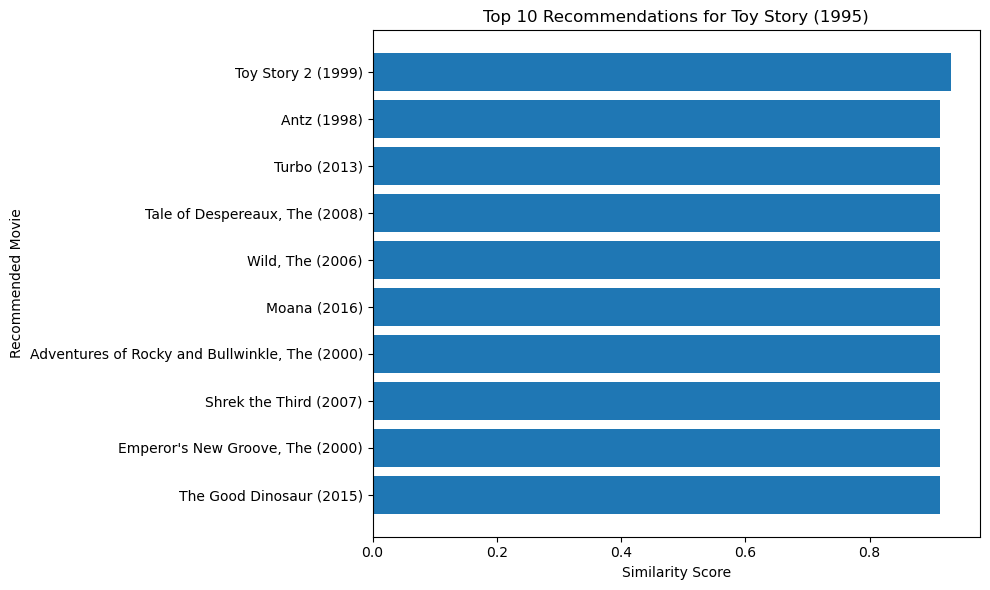

In [40]:
import matplotlib.pyplot as plt

# Get recommendations for Toy Story
toy_story_recommendations = recommend_movies_improved(
    "Toy Story (1995)",
    10
)

# Reverse the order so the highest score appears at the top
toy_story_recommendations = toy_story_recommendations.iloc[::-1]

# Create the chart
plt.figure(figsize=(10, 6))

plt.barh(
    toy_story_recommendations["title"],
    toy_story_recommendations["similarity_score"]
)

plt.xlabel("Similarity Score")
plt.ylabel("Recommended Movie")
plt.title("Top 10 Recommendations for Toy Story (1995)")

plt.tight_layout()
plt.show()

In [41]:
# Save the recommendation chart
plt.savefig(
    "../Data/Final/toy_story_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [42]:
import os

chart_path = "../Data/Final/toy_story_recommendations.png"

print("Chart exists:", os.path.exists(chart_path))

if os.path.exists(chart_path):
    print("Chart location:", os.path.abspath(chart_path))
    print("File size:", os.path.getsize(chart_path), "bytes")

Chart exists: True
Chart location: c:\Users\baitu\OneDrive\Desktop\Capstone-8-Recommendation-System\Data\Final\toy_story_recommendations.png
File size: 15128 bytes


In [43]:
# Save Toy Story recommendations as a CSV file
toy_story_recommendations = recommend_movies_improved(
    "Toy Story (1995)",
    10
)

toy_story_recommendations.to_csv(
    "../Data/Final/toy_story_recommendations.csv",
    index=False
)

print("Recommendation results saved successfully!")

Recommendation results saved successfully!


In [44]:
import os
import pandas as pd

file_path = "../Data/Final/toy_story_recommendations.csv"

print("File exists:", os.path.exists(file_path))

if os.path.exists(file_path):
    print("File location:", os.path.abspath(file_path))
    
    recommendations = pd.read_csv(file_path)
    
    print("Number of recommendations:", len(recommendations))
    print("Columns:", list(recommendations.columns))
    
    display(recommendations)

File exists: True
File location: c:\Users\baitu\OneDrive\Desktop\Capstone-8-Recommendation-System\Data\Final\toy_story_recommendations.csv
Number of recommendations: 10
Columns: ['movieId', 'title', 'similarity_score']


,movieId,title,similarity_score
0,3114,Toy Story 2 (1999),0.931271
1,2294,Antz (1998),0.912871
2,103755,Turbo (2013),0.912871
3,65577,"Tale of Despereaux, The (2008)",0.912871
4,45074,"Wild, The (2006)",0.912871
5,166461,Moana (2016),0.912871
6,3754,"Adventures of Rocky and Bullwinkle, The (2000)",0.912871
7,53121,Shrek the Third (2007),0.912871
8,4016,"Emperor's New Groove, The (2000)",0.912871
9,136016,The Good Dinosaur (2015),0.912871


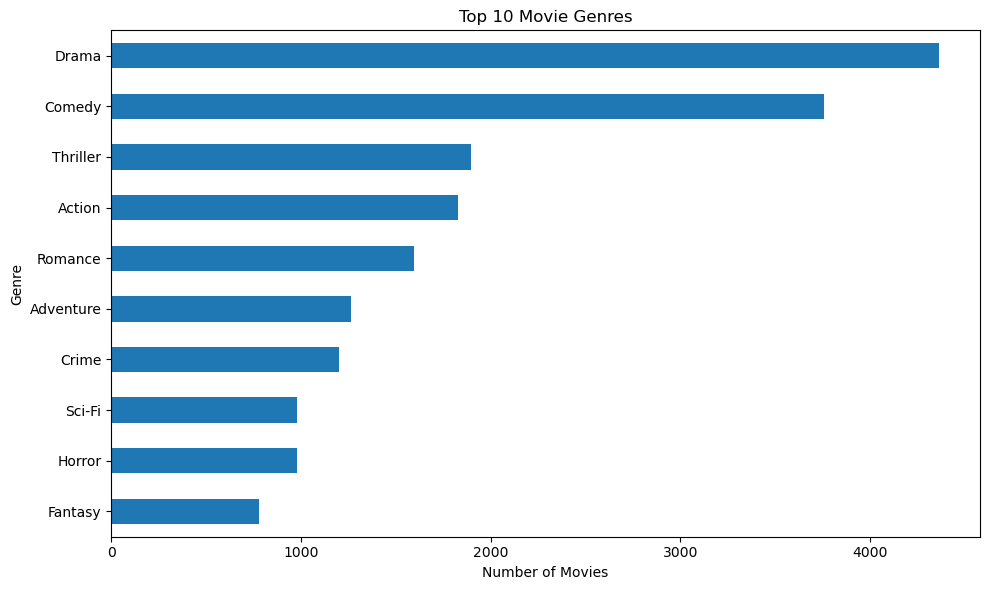

In [45]:
import matplotlib.pyplot as plt

genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

genre_counts = genre_counts.drop("(no genres listed)", errors="ignore")

plt.figure(figsize=(10, 6))

genre_counts.head(10).sort_values().plot(kind="barh")

plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.title("Top 10 Movie Genres")

plt.tight_layout()
plt.show()

In [46]:
# Save the genre distribution chart

plt.savefig(
    "../Data/Final/top_10_movie_genres.png",
    dpi=300,
    bbox_inches="tight"
)

print("Genre chart saved successfully!")

Genre chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [47]:
import os

chart_path = "../Data/Final/top_10_movie_genres.png"

print("Genre chart exists:", os.path.exists(chart_path))

if os.path.exists(chart_path):
    print("Chart location:", os.path.abspath(chart_path))
    print("File size:", os.path.getsize(chart_path), "bytes")

Genre chart exists: True
Chart location: c:\Users\baitu\OneDrive\Desktop\Capstone-8-Recommendation-System\Data\Final\top_10_movie_genres.png
File size: 15128 bytes
